# **Stat-RS**

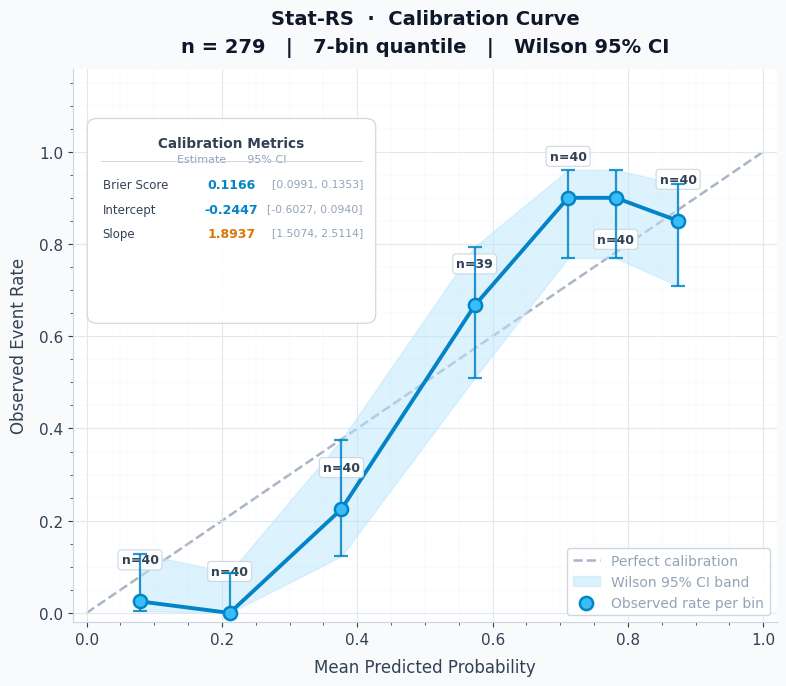

Saved plot 1 to: /content/stat_rs_plot1_calibration_curve.png


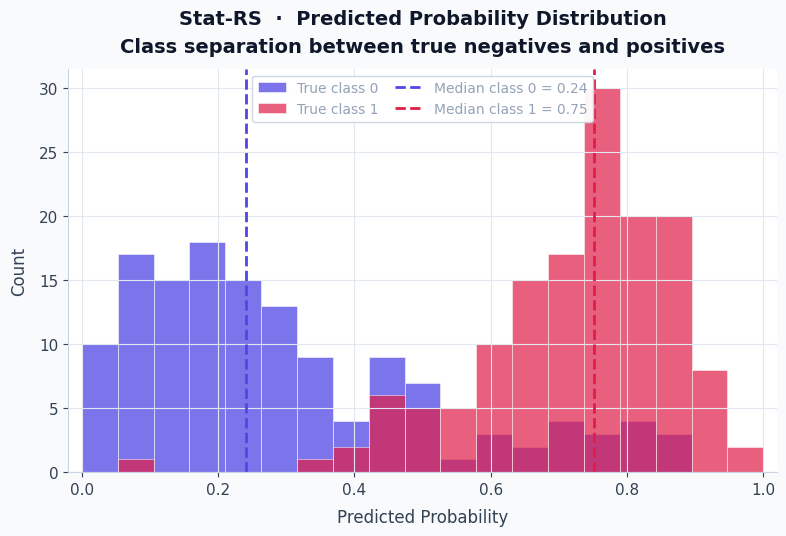

Saved plot 2 to: /content/stat_rs_plot2_probability_dist.png


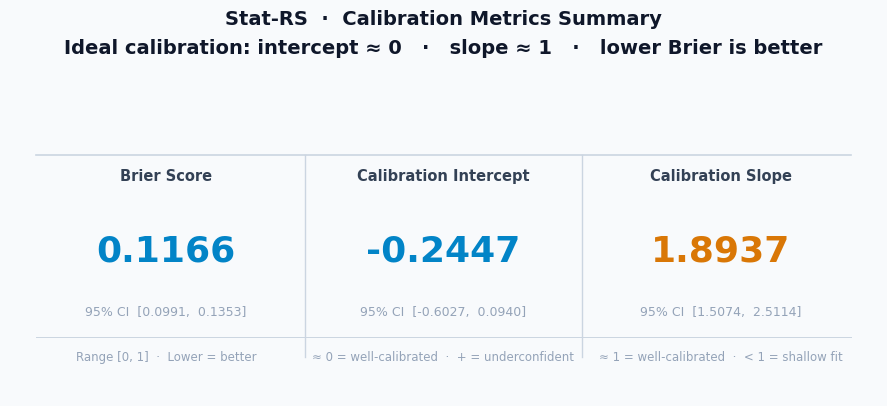

Saved plot 3 to: /content/stat_rs_plot3_metrics_summary.png

Stat-RS Calibration Metrics
               Metric  Estimate    CI low  CI high
          Brier score  0.116564  0.099101 0.135276
Calibration intercept -0.244710 -0.602716 0.093979
    Calibration slope  1.893709  1.507445 2.511422

Saved metrics CSV to: /content/stat_rs_calibration_metrics.csv


In [8]:
import warnings
from pathlib import Path
import pickle
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# =========================================================
# FILES
# =========================================================
MODEL_PATH      = Path("best_lr_model1.pkl")
DATA_PATH       = Path("top_common_features_train80.csv")
OUT_METRICS_CSV = Path("stat_rs_calibration_metrics.csv")
OUT_CALIB_PNG   = Path("stat_rs_plot1_calibration_curve.png")
OUT_HIST_PNG    = Path("stat_rs_plot2_probability_dist.png")
OUT_METRICS_PNG = Path("stat_rs_plot3_metrics_summary.png")

# =========================================================
# SETTINGS
# =========================================================
N_BINS       = 7
N_BOOT       = 3000
RANDOM_STATE = 42
EPS          = 1e-6

# =========================================================
# PALETTE
# =========================================================
BG_FIG    = "#F8FAFC"
BG_PANEL  = "#FFFFFF"
BG_CARD   = "#F1F5F9"
TEAL      = "#0284C7"
TEAL_FILL = "#38BDF8"
TEAL_BAND = "#BAE6FD"
AMBER     = "#D97706"
SLATE_REF = "#94A3B8"
NEG_CLR   = "#4F46E5"
POS_CLR   = "#E11D48"
GRID_CLR  = "#E2E8F0"
BORDER    = "#CBD5E1"
TXT_HI    = "#0F172A"
TXT_MID   = "#334155"
TXT_DIM   = "#94A3B8"

plt.rcParams.update({
    "figure.facecolor" : BG_FIG,
    "axes.facecolor"   : BG_PANEL,
    "axes.edgecolor"   : BORDER,
    "axes.labelcolor"  : TXT_MID,
    "axes.titlecolor"  : TXT_HI,
    "axes.titlesize"   : 14,
    "axes.labelsize"   : 12,
    "xtick.color"      : TXT_MID,
    "ytick.color"      : TXT_MID,
    "xtick.labelsize"  : 11,
    "ytick.labelsize"  : 11,
    "grid.color"       : GRID_CLR,
    "grid.linewidth"   : 0.8,
    "legend.frameon"   : True,
    "legend.framealpha": 0.95,
    "legend.edgecolor" : BORDER,
    "legend.fontsize"  : 10,
    "font.family"      : "DejaVu Sans",
    "font.size"        : 11,
    "savefig.dpi"      : 300,
    "savefig.facecolor": BG_FIG,
})

# =========================================================
# DATA HELPERS
# =========================================================
def load_model(path):
    try:
        return joblib.load(path)
    except Exception:
        with open(path, "rb") as f:
            return pickle.load(f)

def infer_target_column(df):
    for c in ["TYPE", "target", "Target", "label", "Label", "y", "Y"]:
        if c in df.columns:
            return c
    raise ValueError(f"Cannot infer target. Columns: {list(df.columns)}")

def coerce_binary_target(y):
    y = pd.Series(y).copy()
    uniq = set(y.dropna().unique().tolist())
    if uniq.issubset({0, 1}):
        return y.astype(int).to_numpy()
    mapping = {
        "0": 0, "1": 1,
        "no": 0, "yes": 1,
        "negative": 0, "positive": 1,
        "benign": 0, "malignant": 1,
        "non-cancer": 0, "cancer": 1,
        "false": 0, "true": 1
    }
    ys = y.astype(str).str.strip().str.lower()
    if set(ys.unique()).issubset(mapping.keys()):
        return ys.map(mapping).astype(int).to_numpy()
    raise ValueError("Target is not binary and could not be mapped automatically.")

def get_expected_feature_order(model, X):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "named_steps"):
        for step in reversed(list(model.named_steps.values())):
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)
    return list(X.columns)

def wilson_interval(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom  = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    spread = z * np.sqrt((p*(1-p)/n) + (z**2/(4*n**2))) / denom
    return max(0.0, centre - spread), min(1.0, centre + spread)

def calibration_table(y_true, y_prob, n_bins=7):
    df = pd.DataFrame({"y": y_true, "p": y_prob})
    df["bin"] = pd.qcut(df["p"], q=min(n_bins, len(df)), duplicates="drop")
    rows = []
    for _, g in df.groupby("bin", observed=True):
        n = len(g)
        k = int(g["y"].sum())
        lo, hi = wilson_interval(k, n)
        rows.append({
            "mean_pred": g["p"].mean(),
            "obs_rate": g["y"].mean(),
            "ci_low": lo,
            "ci_high": hi,
            "n": n
        })
    return pd.DataFrame(rows).sort_values("mean_pred").reset_index(drop=True)

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    p = np.clip(y_prob, eps, 1-eps)
    logit_p = np.log(p/(1-p)).reshape(-1, 1)
    try:
        lr = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000, random_state=42)
        lr.fit(logit_p, y_true)
    except Exception:
        lr = LogisticRegression(penalty="none", solver="lbfgs", max_iter=5000, random_state=42)
        lr.fit(logit_p, y_true)
    return float(lr.intercept_[0]), float(lr.coef_[0][0])

def bootstrap_cis(y_true, y_prob, n_boot=3000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    bv, iv, sv = [], [], []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yb, pb = y_true[idx], y_prob[idx]

        if len(np.unique(yb)) < 2:
            continue

        try:
            bv.append(brier_score_loss(yb, pb))
            i, s = calibration_intercept_slope(yb, pb)
            iv.append(i)
            sv.append(s)
        except Exception:
            continue

    return {
        "brier"    : np.quantile(bv, [0.025, 0.975]),
        "intercept": np.quantile(iv, [0.025, 0.975]),
        "slope"    : np.quantile(sv, [0.025, 0.975]),
    }

# =========================================================
# COLLISION-FREE BIN LABELS
# =========================================================
def place_bin_labels(ax, xs, ys, ns):
    placed = []
    X_GAP, Y_GAP = 0.10, 0.10

    for x, y, n in zip(xs, ys, ns):
        best_y = None
        for sign in [+1, -1, +2, -2, +3, -3]:
            offset = 0.09 * abs(sign)
            cand_y = np.clip(y + np.sign(sign) * offset, 0.02, 1.08)
            clash = any(abs(cx - x) < X_GAP and abs(cy - cand_y) < Y_GAP for cx, cy in placed)
            if not clash:
                best_y = cand_y
                break
        if best_y is None:
            best_y = np.clip(y + 0.10, 0.02, 1.08)

        placed.append((x, best_y))
        ax.annotate(
            f"n={n}",
            xy=(x, y), xytext=(x, best_y),
            ha="center", va="center",
            fontsize=9, color=TXT_MID, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=BORDER, lw=0.9),
            bbox=dict(boxstyle="round,pad=0.28", fc="white", ec=BORDER, lw=0.8, alpha=0.95),
            annotation_clip=False,
        )

# =========================================================
# SAFE AXES-COORD LINES
# =========================================================
def hline_ax(ax, y_frac, x0=0.03, x1=0.97, **kw):
    line = mlines.Line2D([x0, x1], [y_frac, y_frac], transform=ax.transAxes, clip_on=False, **kw)
    ax.add_line(line)

def vline_ax(ax, x_frac, y0=0.10, y1=0.80, **kw):
    line = mlines.Line2D([x_frac, x_frac], [y0, y1], transform=ax.transAxes, clip_on=False, **kw)
    ax.add_line(line)

# =========================================================
# METRICS TEXT BOX
# =========================================================
def add_metrics_box(ax, brier, intercept, slope, cis):
    brier_good = brier < 0.25
    inter_good = abs(intercept) < 0.3
    slope_good = abs(slope - 1.0) < 0.3

    lines = [
        ("Brier Score", f"{brier:.4f}", f"[{cis['brier'][0]:.4f}, {cis['brier'][1]:.4f}]", brier_good),
        ("Intercept",   f"{intercept:.4f}", f"[{cis['intercept'][0]:.4f}, {cis['intercept'][1]:.4f}]", inter_good),
        ("Slope",       f"{slope:.4f}", f"[{cis['slope'][0]:.4f}, {cis['slope'][1]:.4f}]", slope_good),
    ]

    box = mpatches.FancyBboxPatch(
        (0.035, 0.555), 0.38, 0.34,
        transform=ax.transAxes,
        boxstyle="round,pad=0.015",
        linewidth=0.9, edgecolor=BORDER,
        facecolor="white", alpha=0.93,
        zorder=10, clip_on=False
    )
    ax.add_patch(box)

    ax.text(
        0.225, 0.878, "Calibration Metrics",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=9.8, fontweight="bold",
        color=TXT_MID, zorder=11
    )

    ax.text(
        0.225, 0.846, "Estimate      95% CI",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=8.0,
        color=TXT_DIM, zorder=11
    )

    sep = mlines.Line2D(
        [0.04, 0.41], [0.834, 0.834],
        transform=ax.transAxes,
        color=BORDER, lw=0.7,
        clip_on=False, zorder=11
    )
    ax.add_line(sep)

    row_y = [0.802, 0.758, 0.714]
    for (label, val, ci, good), ry in zip(lines, row_y):
        color = TEAL if good else AMBER

        ax.text(
            0.042, ry, label,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=8.5,
            color=TXT_MID, zorder=11
        )

        ax.text(
            0.225, ry, val,
            transform=ax.transAxes,
            ha="center", va="top",
            fontsize=9.0, fontweight="bold",
            color=color, zorder=11
        )

        ax.text(
            0.412, ry, ci,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=7.8,
            color=TXT_DIM, zorder=11
        )

# =========================================================
# PLOT 1 — Calibration Curve
# =========================================================
def plot_calibration_curve(calib_df, n_total, brier, intercept, slope, cis, out_path):
    fig, ax = plt.subplots(figsize=(8, 7))

    xs     = calib_df["mean_pred"].to_numpy()
    ys     = calib_df["obs_rate"].to_numpy()
    ns     = calib_df["n"].astype(int).to_numpy()
    err_lo = ys - calib_df["ci_low"].to_numpy()
    err_hi = calib_df["ci_high"].to_numpy() - ys

    ax.plot([0, 1], [0, 1], "--", color=SLATE_REF, lw=1.8, alpha=0.8, label="Perfect calibration", zorder=1)

    ax.fill_between(
        xs, calib_df["ci_low"], calib_df["ci_high"],
        color=TEAL_BAND, alpha=0.50, zorder=2,
        label="Wilson 95% CI band"
    )

    ax.plot(xs, ys, color=TEAL, lw=2.8, zorder=3, solid_capstyle="round")

    ax.errorbar(
        xs, ys, yerr=[err_lo, err_hi], fmt="none",
        ecolor=TEAL, elinewidth=1.6, capsize=5,
        capthick=1.6, alpha=0.85, zorder=4
    )

    ax.scatter(
        xs, ys, s=90, color=TEAL_FILL, edgecolor=TEAL,
        linewidth=1.8, zorder=5, label="Observed rate per bin"
    )

    place_bin_labels(ax, xs, ys, ns)
    add_metrics_box(ax, brier, intercept, slope, cis)

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.18)
    ax.set_xlabel("Mean Predicted Probability", labelpad=8)
    ax.set_ylabel("Observed Event Rate", labelpad=8)

    ax.set_title(
        f"Stat-RS  ·  Calibration Curve\n"
        f"n = {n_total:,}   |   {N_BINS}-bin quantile   |   Wilson 95% CI",
        fontsize=14, fontweight="bold", color=TXT_HI,
        pad=12, linespacing=1.6
    )

    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, which="major")
    ax.grid(True, which="minor", lw=0.3, alpha=0.5)
    ax.legend(loc="lower right", fontsize=10)

    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight", facecolor=BG_FIG)
    plt.show()
    print(f"Saved plot 1 to: {out_path.resolve()}")

# =========================================================
# PLOT 2 — Probability Distribution
# =========================================================
def plot_probability_dist(y_true, y_prob, out_path):
    fig, ax = plt.subplots(figsize=(8, 5.5))

    bins = np.linspace(0, 1, 20)
    kw = dict(edgecolor="white", linewidth=0.5)

    ax.hist(y_prob[y_true == 0], bins=bins, alpha=0.75, color=NEG_CLR, label="True class 0", **kw)
    ax.hist(y_prob[y_true == 1], bins=bins, alpha=0.70, color=POS_CLR, label="True class 1", **kw)

    med0 = np.median(y_prob[y_true == 0])
    med1 = np.median(y_prob[y_true == 1])

    ax.axvline(med0, color=NEG_CLR, ls="--", lw=2.0, label=f"Median class 0 = {med0:.2f}")
    ax.axvline(med1, color=POS_CLR, ls="--", lw=2.0, label=f"Median class 1 = {med1:.2f}")

    ax.set_xlabel("Predicted Probability", labelpad=8)
    ax.set_ylabel("Count", labelpad=8)

    ax.set_title(
        "Stat-RS  ·  Predicted Probability Distribution\n"
        "Class separation between true negatives and positives",
        fontsize=14, fontweight="bold", color=TXT_HI,
        pad=12, linespacing=1.6
    )

    ax.set_xlim(-0.02, 1.02)
    ax.grid(True)
    ax.legend(loc="upper center", ncol=2, columnspacing=1.2, fontsize=10)

    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight", facecolor=BG_FIG)
    plt.show()
    print(f"Saved plot 2 to: {out_path.resolve()}")

# =========================================================
# PLOT 3 — Metrics Summary Card
# =========================================================
def plot_metrics_summary(brier, intercept, slope, cis, out_path):
    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.set_facecolor(BG_CARD)
    ax.axis("off")

    ax.set_title(
        "Stat-RS  ·  Calibration Metrics Summary\n"
        "Ideal calibration: intercept ≈ 0   ·   slope ≈ 1   ·   lower Brier is better",
        fontsize=14, fontweight="bold", color=TXT_HI,
        pad=12, linespacing=1.7
    )

    hline_ax(ax, 0.74, color=BORDER, lw=1.2)

    metrics = [
        ("Brier Score",           brier,     cis["brier"][0],     cis["brier"][1],     brier < 0.25),
        ("Calibration Intercept", intercept, cis["intercept"][0], cis["intercept"][1], abs(intercept) < 0.3),
        ("Calibration Slope",     slope,     cis["slope"][0],     cis["slope"][1],     abs(slope - 1.0) < 0.3),
    ]
    cols_x = [0.18, 0.50, 0.82]

    for x, (name, val, lo, hi, good) in zip(cols_x, metrics):
        color = TEAL if good else AMBER
        ax.text(x, 0.70, name, transform=ax.transAxes, ha="center", va="top",
                fontsize=10.5, color=TXT_MID, fontweight="bold")
        ax.text(x, 0.50, f"{val:.4f}", transform=ax.transAxes, ha="center", va="top",
                fontsize=26, color=color, fontweight="bold")
        ax.text(x, 0.28, f"95% CI  [{lo:.4f},  {hi:.4f}]", transform=ax.transAxes, ha="center", va="top",
                fontsize=9, color=TXT_DIM)

    for xv in [0.34, 0.66]:
        vline_ax(ax, xv, y0=0.12, y1=0.74, color=BORDER, lw=1.0)

    hline_ax(ax, 0.18, color=BORDER, lw=0.7)

    notes = [
        "Range [0, 1]  ·  Lower = better",
        "≈ 0 = well-calibrated  ·  + = underconfident",
        "≈ 1 = well-calibrated  ·  < 1 = shallow fit",
    ]
    for x, note in zip(cols_x, notes):
        ax.text(x, 0.14, note, transform=ax.transAxes, ha="center", va="top",
                fontsize=8.5, color=TXT_DIM)

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight", facecolor=BG_FIG)
    plt.show()
    print(f"Saved plot 3 to: {out_path.resolve()}")

# =========================================================
# MAIN
# =========================================================
model = load_model(MODEL_PATH)
df = pd.read_csv(DATA_PATH)

target_col = infer_target_column(df)
y = coerce_binary_target(df[target_col])
X = df.drop(columns=[target_col])

expected_cols = get_expected_feature_order(model, X)
missing = [c for c in expected_cols if c not in X.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

X = X[expected_cols]
y_prob = model.predict_proba(X)[:, 1]

brier = float(brier_score_loss(y, y_prob))
intercept, slope = calibration_intercept_slope(y, y_prob)
cis = bootstrap_cis(y, y_prob, n_boot=N_BOOT, random_state=RANDOM_STATE)
calib_df = calibration_table(y, y_prob, n_bins=N_BINS)

metrics_df = pd.DataFrame({
    "Metric"  : ["Brier score", "Calibration intercept", "Calibration slope"],
    "Estimate": [brier, intercept, slope],
    "CI low"  : [cis["brier"][0], cis["intercept"][0], cis["slope"][0]],
    "CI high" : [cis["brier"][1], cis["intercept"][1], cis["slope"][1]],
})
metrics_df.to_csv(OUT_METRICS_CSV, index=False)

plot_calibration_curve(calib_df, len(y), brier, intercept, slope, cis, OUT_CALIB_PNG)
plot_probability_dist(y, y_prob, OUT_HIST_PNG)
plot_metrics_summary(brier, intercept, slope, cis, OUT_METRICS_PNG)

print("\nStat-RS Calibration Metrics")
print(metrics_df.to_string(index=False))
print(f"\nSaved metrics CSV to: {OUT_METRICS_CSV.resolve()}")

# **Stat-AQ**

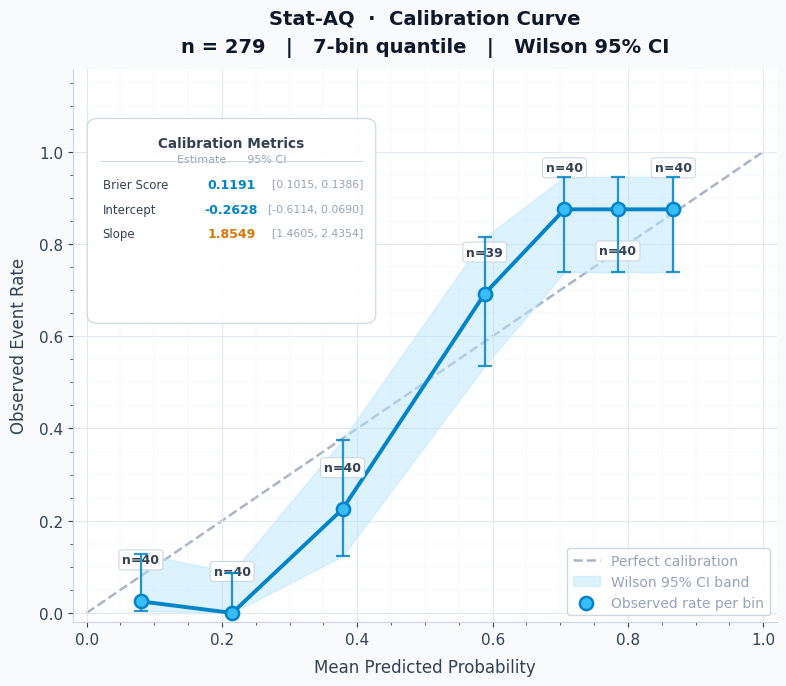

Saved plot 1 to: /content/stat_aq_plot1_calibration_curve.png


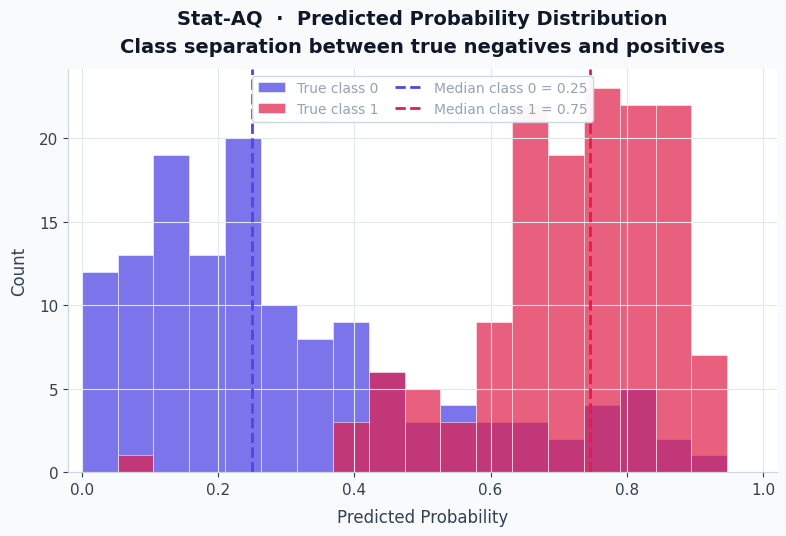

Saved plot 2 to: /content/stat_aq_plot2_probability_dist.png


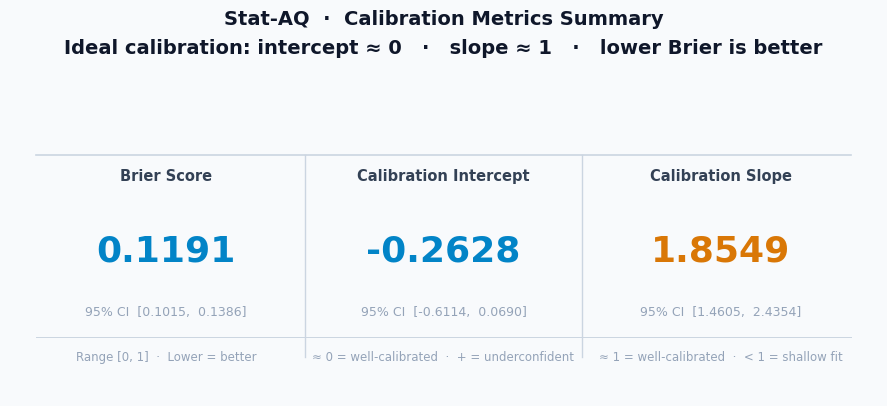

Saved plot 3 to: /content/stat_aq_plot3_metrics_summary.png

Stat-AQ Calibration Metrics
               Metric  Estimate    CI low  CI high
          Brier score  0.119116  0.101451 0.138645
Calibration intercept -0.262848 -0.611423 0.068974
    Calibration slope  1.854917  1.460527 2.435401

Saved metrics CSV to: /content/stat_aq_calibration_metrics.csv


In [9]:
import warnings
from pathlib import Path
import pickle
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# =========================================================
# FILES
# =========================================================
MODEL_PATH      = Path("best_lr_model2.pkl")
DATA_PATH       = Path("combined_features_train80.csv")
OUT_METRICS_CSV = Path("stat_aq_calibration_metrics.csv")
OUT_CALIB_PNG   = Path("stat_aq_plot1_calibration_curve.png")
OUT_HIST_PNG    = Path("stat_aq_plot2_probability_dist.png")
OUT_METRICS_PNG = Path("stat_aq_plot3_metrics_summary.png")

# =========================================================
# SETTINGS
# =========================================================
N_BINS       = 7
N_BOOT       = 3000
RANDOM_STATE = 42
EPS          = 1e-6

# =========================================================
# PALETTE
# =========================================================
BG_FIG    = "#F8FAFC"
BG_PANEL  = "#FFFFFF"
BG_CARD   = "#F1F5F9"
TEAL      = "#0284C7"
TEAL_FILL = "#38BDF8"
TEAL_BAND = "#BAE6FD"
AMBER     = "#D97706"
SLATE_REF = "#94A3B8"
NEG_CLR   = "#4F46E5"
POS_CLR   = "#E11D48"
GRID_CLR  = "#E2E8F0"
BORDER    = "#CBD5E1"
TXT_HI    = "#0F172A"
TXT_MID   = "#334155"
TXT_DIM   = "#94A3B8"

plt.rcParams.update({
    "figure.facecolor" : BG_FIG,
    "axes.facecolor"   : BG_PANEL,
    "axes.edgecolor"   : BORDER,
    "axes.labelcolor"  : TXT_MID,
    "axes.titlecolor"  : TXT_HI,
    "axes.titlesize"   : 14,
    "axes.labelsize"   : 12,
    "xtick.color"      : TXT_MID,
    "ytick.color"      : TXT_MID,
    "xtick.labelsize"  : 11,
    "ytick.labelsize"  : 11,
    "grid.color"       : GRID_CLR,
    "grid.linewidth"   : 0.8,
    "legend.frameon"   : True,
    "legend.framealpha": 0.95,
    "legend.edgecolor" : BORDER,
    "legend.fontsize"  : 10,
    "font.family"      : "DejaVu Sans",
    "font.size"        : 11,
    "savefig.dpi"      : 300,
    "savefig.facecolor": BG_FIG,
})

# =========================================================
# DATA HELPERS
# =========================================================
def load_model(path):
    try:
        return joblib.load(path)
    except Exception:
        with open(path, "rb") as f:
            return pickle.load(f)

def infer_target_column(df):
    for c in ["TYPE", "target", "Target", "label", "Label", "y", "Y"]:
        if c in df.columns:
            return c
    raise ValueError(f"Cannot infer target. Columns: {list(df.columns)}")

def coerce_binary_target(y):
    y = pd.Series(y).copy()
    uniq = set(y.dropna().unique().tolist())
    if uniq.issubset({0, 1}):
        return y.astype(int).to_numpy()
    mapping = {
        "0": 0, "1": 1,
        "no": 0, "yes": 1,
        "negative": 0, "positive": 1,
        "benign": 0, "malignant": 1,
        "non-cancer": 0, "cancer": 1,
        "false": 0, "true": 1
    }
    ys = y.astype(str).str.strip().str.lower()
    if set(ys.unique()).issubset(mapping.keys()):
        return ys.map(mapping).astype(int).to_numpy()
    raise ValueError("Target is not binary and could not be mapped automatically.")

def get_expected_feature_order(model, X):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "named_steps"):
        for step in reversed(list(model.named_steps.values())):
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)
    return list(X.columns)

def wilson_interval(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom  = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    spread = z * np.sqrt((p*(1-p)/n) + (z**2/(4*n**2))) / denom
    return max(0.0, centre - spread), min(1.0, centre + spread)

def calibration_table(y_true, y_prob, n_bins=7):
    df = pd.DataFrame({"y": y_true, "p": y_prob})
    df["bin"] = pd.qcut(df["p"], q=min(n_bins, len(df)), duplicates="drop")
    rows = []
    for _, g in df.groupby("bin", observed=True):
        n = len(g)
        k = int(g["y"].sum())
        lo, hi = wilson_interval(k, n)
        rows.append({
            "mean_pred": g["p"].mean(),
            "obs_rate": g["y"].mean(),
            "ci_low": lo,
            "ci_high": hi,
            "n": n
        })
    return pd.DataFrame(rows).sort_values("mean_pred").reset_index(drop=True)

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    p = np.clip(y_prob, eps, 1-eps)
    logit_p = np.log(p/(1-p)).reshape(-1, 1)
    try:
        lr = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000, random_state=42)
        lr.fit(logit_p, y_true)
    except Exception:
        lr = LogisticRegression(penalty="none", solver="lbfgs", max_iter=5000, random_state=42)
        lr.fit(logit_p, y_true)
    return float(lr.intercept_[0]), float(lr.coef_[0][0])

def bootstrap_cis(y_true, y_prob, n_boot=3000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    bv, iv, sv = [], [], []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yb, pb = y_true[idx], y_prob[idx]

        if len(np.unique(yb)) < 2:
            continue

        try:
            bv.append(brier_score_loss(yb, pb))
            i, s = calibration_intercept_slope(yb, pb)
            iv.append(i)
            sv.append(s)
        except Exception:
            continue

    return {
        "brier"    : np.quantile(bv, [0.025, 0.975]),
        "intercept": np.quantile(iv, [0.025, 0.975]),
        "slope"    : np.quantile(sv, [0.025, 0.975]),
    }

# =========================================================
# COLLISION-FREE BIN LABELS
# =========================================================
def place_bin_labels(ax, xs, ys, ns):
    placed = []
    X_GAP, Y_GAP = 0.10, 0.10

    for x, y, n in zip(xs, ys, ns):
        best_y = None
        for sign in [+1, -1, +2, -2, +3, -3]:
            offset = 0.09 * abs(sign)
            cand_y = np.clip(y + np.sign(sign) * offset, 0.02, 1.08)
            clash = any(abs(cx - x) < X_GAP and abs(cy - cand_y) < Y_GAP for cx, cy in placed)
            if not clash:
                best_y = cand_y
                break
        if best_y is None:
            best_y = np.clip(y + 0.10, 0.02, 1.08)

        placed.append((x, best_y))
        ax.annotate(
            f"n={n}",
            xy=(x, y), xytext=(x, best_y),
            ha="center", va="center",
            fontsize=9, color=TXT_MID, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=BORDER, lw=0.9),
            bbox=dict(boxstyle="round,pad=0.28", fc="white", ec=BORDER, lw=0.8, alpha=0.95),
            annotation_clip=False,
        )

# =========================================================
# SAFE AXES-COORD LINES
# =========================================================
def hline_ax(ax, y_frac, x0=0.03, x1=0.97, **kw):
    line = mlines.Line2D([x0, x1], [y_frac, y_frac], transform=ax.transAxes, clip_on=False, **kw)
    ax.add_line(line)

def vline_ax(ax, x_frac, y0=0.10, y1=0.80, **kw):
    line = mlines.Line2D([x_frac, x_frac], [y0, y1], transform=ax.transAxes, clip_on=False, **kw)
    ax.add_line(line)

# =========================================================
# METRICS TEXT BOX
# =========================================================
def add_metrics_box(ax, brier, intercept, slope, cis):
    brier_good = brier < 0.25
    inter_good = abs(intercept) < 0.3
    slope_good = abs(slope - 1.0) < 0.3

    lines = [
        ("Brier Score", f"{brier:.4f}", f"[{cis['brier'][0]:.4f}, {cis['brier'][1]:.4f}]", brier_good),
        ("Intercept",   f"{intercept:.4f}", f"[{cis['intercept'][0]:.4f}, {cis['intercept'][1]:.4f}]", inter_good),
        ("Slope",       f"{slope:.4f}", f"[{cis['slope'][0]:.4f}, {cis['slope'][1]:.4f}]", slope_good),
    ]

    box = mpatches.FancyBboxPatch(
        (0.035, 0.555), 0.38, 0.34,
        transform=ax.transAxes,
        boxstyle="round,pad=0.015",
        linewidth=0.9, edgecolor=BORDER,
        facecolor="white", alpha=0.93,
        zorder=10, clip_on=False
    )
    ax.add_patch(box)

    ax.text(
        0.225, 0.878, "Calibration Metrics",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=9.8, fontweight="bold",
        color=TXT_MID, zorder=11
    )

    ax.text(
        0.225, 0.846, "Estimate      95% CI",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=8.0,
        color=TXT_DIM, zorder=11
    )

    sep = mlines.Line2D(
        [0.04, 0.41], [0.834, 0.834],
        transform=ax.transAxes,
        color=BORDER, lw=0.7,
        clip_on=False, zorder=11
    )
    ax.add_line(sep)

    row_y = [0.802, 0.758, 0.714]
    for (label, val, ci, good), ry in zip(lines, row_y):
        color = TEAL if good else AMBER

        ax.text(
            0.042, ry, label,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=8.5,
            color=TXT_MID, zorder=11
        )

        ax.text(
            0.225, ry, val,
            transform=ax.transAxes,
            ha="center", va="top",
            fontsize=9.0, fontweight="bold",
            color=color, zorder=11
        )

        ax.text(
            0.412, ry, ci,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=7.8,
            color=TXT_DIM, zorder=11
        )

# =========================================================
# PLOT 1 — Calibration Curve
# =========================================================
def plot_calibration_curve(calib_df, n_total, brier, intercept, slope, cis, out_path):
    fig, ax = plt.subplots(figsize=(8, 7))

    xs     = calib_df["mean_pred"].to_numpy()
    ys     = calib_df["obs_rate"].to_numpy()
    ns     = calib_df["n"].astype(int).to_numpy()
    err_lo = ys - calib_df["ci_low"].to_numpy()
    err_hi = calib_df["ci_high"].to_numpy() - ys

    ax.plot([0, 1], [0, 1], "--", color=SLATE_REF, lw=1.8, alpha=0.8, label="Perfect calibration", zorder=1)

    ax.fill_between(
        xs, calib_df["ci_low"], calib_df["ci_high"],
        color=TEAL_BAND, alpha=0.50, zorder=2,
        label="Wilson 95% CI band"
    )

    ax.plot(xs, ys, color=TEAL, lw=2.8, zorder=3, solid_capstyle="round")

    ax.errorbar(
        xs, ys, yerr=[err_lo, err_hi], fmt="none",
        ecolor=TEAL, elinewidth=1.6, capsize=5,
        capthick=1.6, alpha=0.85, zorder=4
    )

    ax.scatter(
        xs, ys, s=90, color=TEAL_FILL, edgecolor=TEAL,
        linewidth=1.8, zorder=5, label="Observed rate per bin"
    )

    place_bin_labels(ax, xs, ys, ns)
    add_metrics_box(ax, brier, intercept, slope, cis)

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.18)
    ax.set_xlabel("Mean Predicted Probability", labelpad=8)
    ax.set_ylabel("Observed Event Rate", labelpad=8)

    ax.set_title(
        f"Stat-AQ  ·  Calibration Curve\n"
        f"n = {n_total:,}   |   {N_BINS}-bin quantile   |   Wilson 95% CI",
        fontsize=14, fontweight="bold", color=TXT_HI,
        pad=12, linespacing=1.6
    )

    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, which="major")
    ax.grid(True, which="minor", lw=0.3, alpha=0.5)
    ax.legend(loc="lower right", fontsize=10)

    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight", facecolor=BG_FIG)
    plt.show()
    print(f"Saved plot 1 to: {out_path.resolve()}")

# =========================================================
# PLOT 2 — Probability Distribution
# =========================================================
def plot_probability_dist(y_true, y_prob, out_path):
    fig, ax = plt.subplots(figsize=(8, 5.5))

    bins = np.linspace(0, 1, 20)
    kw = dict(edgecolor="white", linewidth=0.5)

    ax.hist(y_prob[y_true == 0], bins=bins, alpha=0.75, color=NEG_CLR, label="True class 0", **kw)
    ax.hist(y_prob[y_true == 1], bins=bins, alpha=0.70, color=POS_CLR, label="True class 1", **kw)

    med0 = np.median(y_prob[y_true == 0])
    med1 = np.median(y_prob[y_true == 1])

    ax.axvline(med0, color=NEG_CLR, ls="--", lw=2.0, label=f"Median class 0 = {med0:.2f}")
    ax.axvline(med1, color=POS_CLR, ls="--", lw=2.0, label=f"Median class 1 = {med1:.2f}")

    ax.set_xlabel("Predicted Probability", labelpad=8)
    ax.set_ylabel("Count", labelpad=8)

    ax.set_title(
        "Stat-AQ  ·  Predicted Probability Distribution\n"
        "Class separation between true negatives and positives",
        fontsize=14, fontweight="bold", color=TXT_HI,
        pad=12, linespacing=1.6
    )

    ax.set_xlim(-0.02, 1.02)
    ax.grid(True)
    ax.legend(loc="upper center", ncol=2, columnspacing=1.2, fontsize=10)

    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight", facecolor=BG_FIG)
    plt.show()
    print(f"Saved plot 2 to: {out_path.resolve()}")

# =========================================================
# PLOT 3 — Metrics Summary Card
# =========================================================
def plot_metrics_summary(brier, intercept, slope, cis, out_path):
    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.set_facecolor(BG_CARD)
    ax.axis("off")

    ax.set_title(
        "Stat-AQ  ·  Calibration Metrics Summary\n"
        "Ideal calibration: intercept ≈ 0   ·   slope ≈ 1   ·   lower Brier is better",
        fontsize=14, fontweight="bold", color=TXT_HI,
        pad=12, linespacing=1.7
    )

    hline_ax(ax, 0.74, color=BORDER, lw=1.2)

    metrics = [
        ("Brier Score",           brier,     cis["brier"][0],     cis["brier"][1],     brier < 0.25),
        ("Calibration Intercept", intercept, cis["intercept"][0], cis["intercept"][1], abs(intercept) < 0.3),
        ("Calibration Slope",     slope,     cis["slope"][0],     cis["slope"][1],     abs(slope - 1.0) < 0.3),
    ]
    cols_x = [0.18, 0.50, 0.82]

    for x, (name, val, lo, hi, good) in zip(cols_x, metrics):
        color = TEAL if good else AMBER
        ax.text(x, 0.70, name, transform=ax.transAxes, ha="center", va="top",
                fontsize=10.5, color=TXT_MID, fontweight="bold")
        ax.text(x, 0.50, f"{val:.4f}", transform=ax.transAxes, ha="center", va="top",
                fontsize=26, color=color, fontweight="bold")
        ax.text(x, 0.28, f"95% CI  [{lo:.4f},  {hi:.4f}]", transform=ax.transAxes, ha="center", va="top",
                fontsize=9, color=TXT_DIM)

    for xv in [0.34, 0.66]:
        vline_ax(ax, xv, y0=0.12, y1=0.74, color=BORDER, lw=1.0)

    hline_ax(ax, 0.18, color=BORDER, lw=0.7)

    notes = [
        "Range [0, 1]  ·  Lower = better",
        "≈ 0 = well-calibrated  ·  + = underconfident",
        "≈ 1 = well-calibrated  ·  < 1 = shallow fit",
    ]
    for x, note in zip(cols_x, notes):
        ax.text(x, 0.14, note, transform=ax.transAxes, ha="center", va="top",
                fontsize=8.5, color=TXT_DIM)

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight", facecolor=BG_FIG)
    plt.show()
    print(f"Saved plot 3 to: {out_path.resolve()}")

# =========================================================
# MAIN
# =========================================================
model = load_model(MODEL_PATH)
df = pd.read_csv(DATA_PATH)

target_col = infer_target_column(df)
y = coerce_binary_target(df[target_col])
X = df.drop(columns=[target_col])

expected_cols = get_expected_feature_order(model, X)
missing = [c for c in expected_cols if c not in X.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

X = X[expected_cols]
y_prob = model.predict_proba(X)[:, 1]

brier = float(brier_score_loss(y, y_prob))
intercept, slope = calibration_intercept_slope(y, y_prob)
cis = bootstrap_cis(y, y_prob, n_boot=N_BOOT, random_state=RANDOM_STATE)
calib_df = calibration_table(y, y_prob, n_bins=N_BINS)

metrics_df = pd.DataFrame({
    "Metric"  : ["Brier score", "Calibration intercept", "Calibration slope"],
    "Estimate": [brier, intercept, slope],
    "CI low"  : [cis["brier"][0], cis["intercept"][0], cis["slope"][0]],
    "CI high" : [cis["brier"][1], cis["intercept"][1], cis["slope"][1]],
})
metrics_df.to_csv(OUT_METRICS_CSV, index=False)

plot_calibration_curve(calib_df, len(y), brier, intercept, slope, cis, OUT_CALIB_PNG)
plot_probability_dist(y, y_prob, OUT_HIST_PNG)
plot_metrics_summary(brier, intercept, slope, cis, OUT_METRICS_PNG)

print("\nStat-AQ Calibration Metrics")
print(metrics_df.to_string(index=False))
print(f"\nSaved metrics CSV to: {OUT_METRICS_CSV.resolve()}")